<a href="https://colab.research.google.com/github/KrishnaAkshath/ML-diamond-price-prdiction-system/blob/main/Diamond_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving diamonds.csv to diamonds (6).csv
R² Score: 0.9809510113421867
RMSE: 550.2893525413056
Sample predictions: [  566.2    2310.77   1211.585  1253.97  10059.025]


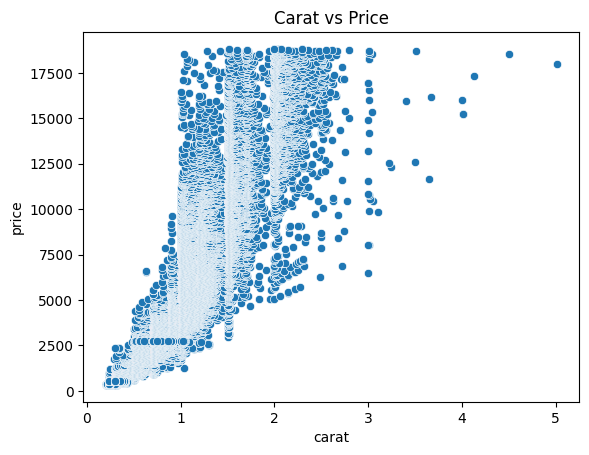

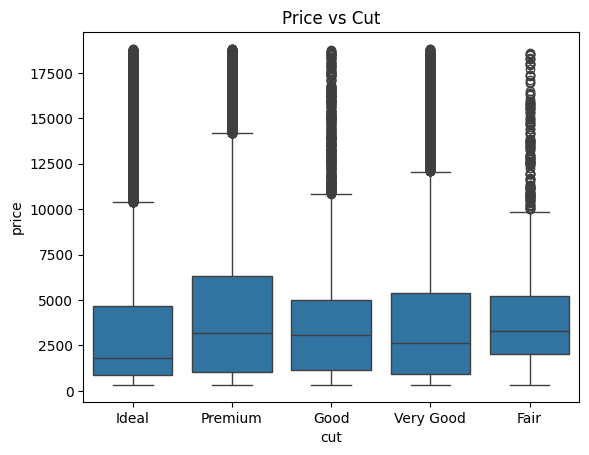

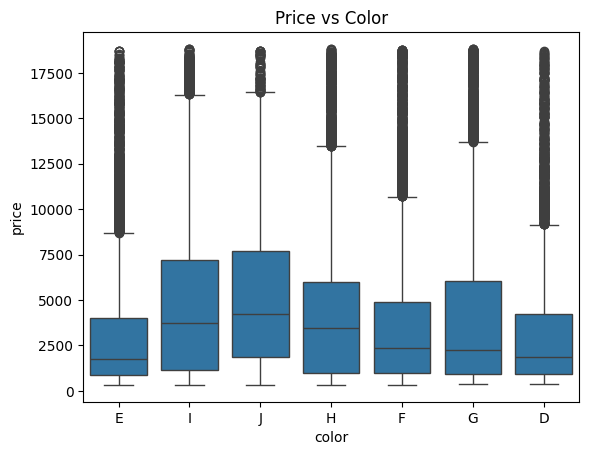

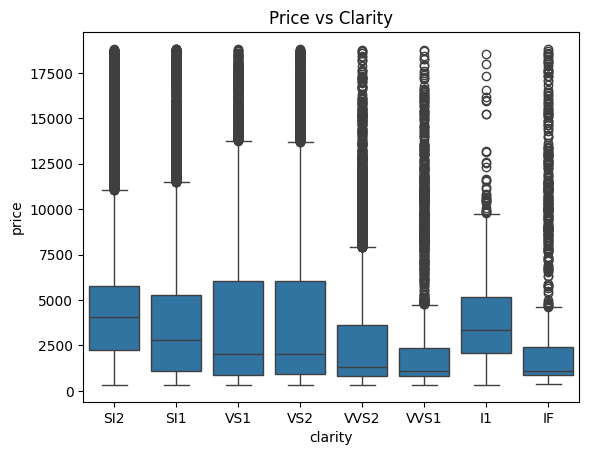

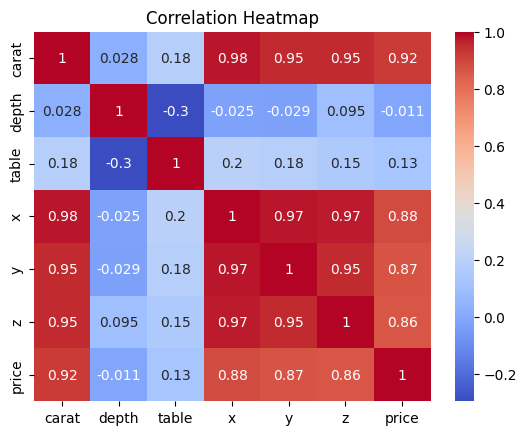

        feature  importance
20        carat    0.628822
24            y    0.257227
15  clarity_SI2    0.019441
12   clarity_I1    0.015000
14  clarity_SI1    0.014450
11      color_J    0.010343
10      color_I    0.007245
17  clarity_VS2    0.007099
9       color_H    0.005639
16  clarity_VS1    0.005601
23            x    0.005576
25            z    0.005257
21        depth    0.003184
5       color_D    0.002826
8       color_G    0.002596


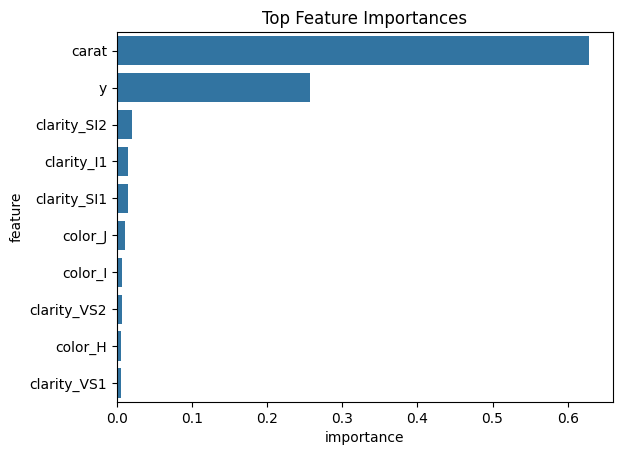

Model saved as diamond_price_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Upload and load dataset
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("diamonds.csv")
df = df.drop(columns=['Unnamed: 0'])   # remove unnecessary index column


# Prepare features (X) and target (y)
X = df.drop('price', axis=1)
y = df['price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Build preprocessing + model pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

categorical_features = ['cut', 'color', 'clarity']
numerical_features   = ['carat', 'depth', 'table', 'x', 'y', 'z']

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numerical_features)
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, random_state=42))
])


# Train model
model.fit(X_train, y_train)


# Evaluate model
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print("RMSE:", rmse)

print("Sample predictions:", model.predict(X_test.iloc[:5]))


# Basic EDA (understanding relationships in data)
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['carat'], y=df['price'])
plt.title("Carat vs Price")
plt.show()

sns.boxplot(x='cut', y='price', data=df)
plt.title("Price vs Cut")
plt.show()

sns.boxplot(x='color', y='price', data=df)
plt.title("Price vs Color")
plt.show()

sns.boxplot(x='clarity', y='price', data=df)
plt.title("Price vs Clarity")
plt.show()

numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Feature importance (what affects price most)
import numpy as np

ohe = model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = np.concatenate([encoded_cat_names, numerical_features])

rf = model.named_steps['regressor']
importances = rf.feature_importances_

fi = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(fi.head(15))

sns.barplot(x='importance', y='feature', data=fi.head(10))
plt.title("Top Feature Importances")
plt.show()


# Save trained model
import joblib
joblib.dump(model, "diamond_price_model.pkl")
print("Model saved as diamond_price_model.pkl")


from google.colab import files
files.download("diamond_price_model.pkl")
